<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Yeast/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 100)
plt.rcParams["figure.dpi"] = 110

# Load the file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Yeast/'

cols = ["Sequence_Name", "mcg", "gvh", "alm", "mit", "erl", "pox", "vac", "nuc", "class"]
df_raw = pd.read_csv(data_dir + "yeast.data", sep=r"\s+", names=cols)
df_raw = df_raw.drop(columns=["Sequence_Name"])
print("Shape:", df_raw.shape)
df_raw.head()

Mounted at /content/drive
Shape: (1484, 9)


,mcg,gvh,alm,mit,erl,pox,vac,nuc,class
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


# Basic dataset structure

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     1484 non-null   float64
 1   gvh     1484 non-null   float64
 2   alm     1484 non-null   float64
 3   mit     1484 non-null   float64
 4   erl     1484 non-null   float64
 5   pox     1484 non-null   float64
 6   vac     1484 non-null   float64
 7   nuc     1484 non-null   float64
 8   class   1484 non-null   object 
dtypes: float64(8), object(1)
memory usage: 104.5+ KB


no missing values

# Target value exploration

In [ ]:
print("Target variable:", "class")
print("Unique classes:", sorted(df_raw["class"].unique()))
print("Number of classes:", df_raw["class"].nunique())
df_raw["class"].value_counts().sort_index()

Target variable: class
Unique classes: ['CYT', 'ERL', 'EXC', 'ME1', 'ME2', 'ME3', 'MIT', 'NUC', 'POX', 'VAC']
Number of classes: 10


,count
class,
CYT,463
ERL,5
EXC,35
ME1,44
ME2,51
ME3,163
MIT,244
NUC,429
POX,20


All the 10 classes have instances.

# Missing values check

In [ ]:
# From df_raw.info() we likely already saw no missing values but let's confirm here

print("Missing values (total):", df_raw.isna().sum().sum())
df_raw.isna().sum()

Missing values (total): 0


,0
mcg,0
gvh,0
alm,0
mit,0
erl,0
pox,0
vac,0
nuc,0
class,0


# Exact duplicate rows check

In [ ]:
dup_mask = df_raw.duplicated(keep=False)
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
df_raw[dup_mask]

Duplicate rows: 31


,mcg,gvh,alm,mit,erl,pox,vac,nuc,class
160,0.40,0.42,0.71,0.21,0.5,0.0,0.54,0.32,CYT
161,0.40,0.42,0.71,0.21,0.5,0.0,0.54,0.32,CYT
236,0.38,0.51,0.75,0.17,0.5,0.0,0.55,0.22,CYT
237,0.38,0.51,0.75,0.17,0.5,0.0,0.55,0.22,CYT
406,0.37,0.34,0.58,0.24,0.5,0.0,0.44,0.18,NUC
...,...,...,...,...,...,...,...,...,...
1242,0.63,0.43,0.48,0.11,0.5,0.0,0.51,0.22,CYT
1243,0.63,0.43,0.48,0.11,0.5,0.0,0.51,0.22,CYT
1256,0.38,0.42,0.50,0.19,0.5,0.0,0.44,0.22,CYT
1258,0.38,0.42,0.50,0.19,0.5,0.0,0.44,0.22,CYT


 The duplicate observations were removed to prevent the same observation from potentially appearing in both the training and test sets. Removal of this also does not affect the minority to majority class ordering.

In [ ]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (1453, 9)


# Duplicate feature vectors with different labels check

In [ ]:
feature_cols = [c for c in df.columns if c != "class"]
feature_dup_mask = df.duplicated(subset=feature_cols, keep=False)
print("Rows with identical features but (possibly) different labels:", feature_dup_mask.sum())
df[feature_dup_mask].sort_values(feature_cols)

Rows with identical features but (possibly) different labels: 0


,mcg,gvh,alm,mit,erl,pox,vac,nuc,class


# Class distribution and minority to majority ordering

In [ ]:
counts = df["class"].value_counts().sort_values()
total = len(df)
dist_table = pd.DataFrame({
    "class_label": counts.index,
    "count": counts.values,
    "pct": (counts.values / total * 100).round(2),
})
dist_table["rank_minority_to_majority"] = range(1, len(dist_table) + 1)
dist_table

,class_label,count,pct,rank_minority_to_majority
0,ERL,5,0.34,1
1,POX,20,1.38,2
2,VAC,30,2.06,3
3,EXC,35,2.41,4
4,ME1,43,2.96,5
5,ME2,51,3.51,6
6,ME3,162,11.15,7
7,MIT,244,16.79,8
8,NUC,425,29.25,9
9,CYT,438,30.14,10


# Ordering and the imbalance ratio

In [ ]:
minority_to_majority_order = dist_table["class_label"].tolist()
imbalance_ratio = counts.max() / counts.min()

print("Minority -> majority order:", minority_to_majority_order)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

Minority -> majority order: ['ERL', 'POX', 'VAC', 'EXC', 'ME1', 'ME2', 'ME3', 'MIT', 'NUC', 'CYT']
Imbalance ratio (majority/minority): 87.60


# Class distribution bar chat

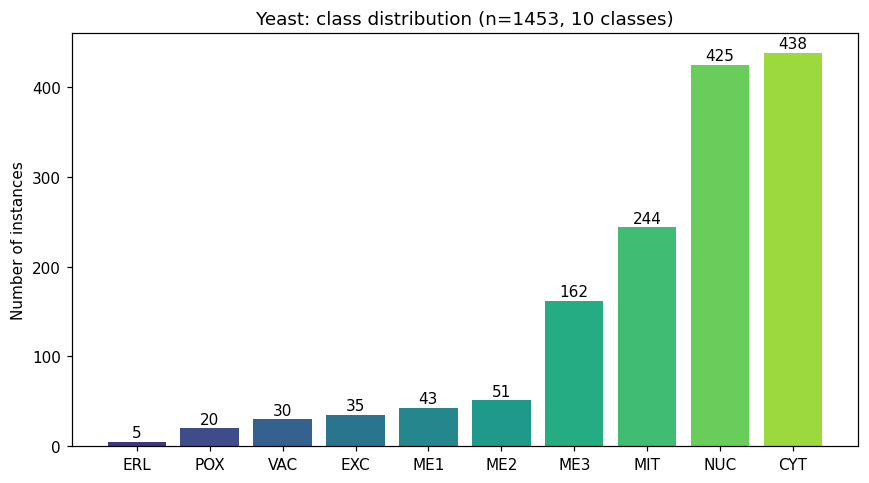

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dist_table)))
ax.bar(dist_table["class_label"], dist_table["count"], color=colors)
for i, v in enumerate(dist_table["count"]):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10)
ax.set_ylabel("Number of instances")
ax.set_title(f"Yeast: class distribution (n={total}, 10 classes)")
plt.tight_layout()
plt.show()

# Descriptive statistics

In [ ]:
def continuous_dqr(df, cols):
    n = len(df)
    rows = []
    for c in cols:
        s = df[c]
        count = s.count()
        rows.append({
            "Feature": c, "Count": count, "% Miss.": round((n - count) / n * 100, 2),
            "Card.": s.nunique(), "Min.": s.min(), "1st Qrt.": s.quantile(0.25),
            "Mean": s.mean(), "Median": s.median(), "3rd Qrt.": s.quantile(0.75),
            "Max.": s.max(), "Std. Dev.": s.std(),
        })
    out = pd.DataFrame(rows)
    num_cols = ["Min.", "1st Qrt.", "Mean", "Median", "3rd Qrt.", "Max.", "Std. Dev."]
    out[num_cols] = out[num_cols].round(3)
    return out

def categorical_dqr(df, cols, label_map=None):
    n = len(df)
    rows = []
    for c in cols:
        s = df[c]
        count = s.count()
        vc = s.value_counts()
        mode, mode_freq = vc.index[0], int(vc.iloc[0])
        mode_pct = round(mode_freq / count * 100, 2)
        if len(vc) > 1:
            mode2, mode2_freq = vc.index[1], int(vc.iloc[1])
            mode2_pct = round(mode2_freq / count * 100, 2)
        else:
            mode2, mode2_freq, mode2_pct = np.nan, 0, 0.0
        rows.append({
            "Feature": c, "Count": count, "% Miss.": round((n - count) / n * 100, 2),
            "Card.": s.nunique(), "Mode": mode, "Mode Freq.": mode_freq, "Mode %": mode_pct,
            "2nd Mode": mode2, "2nd Mode Freq.": mode2_freq, "2nd Mode %": mode2_pct,
        })
    return pd.DataFrame(rows)

# Descriptive features: all 8 are continuous — no categorical descriptive
# features in this dataset, so there is no separate descriptive-categorical table.
continuous_dqr_table = continuous_dqr(df, feature_cols)

# class is the TARGET, not a descriptive feature — its own table, same
# column order as the categorical DQR format. No label_map needed here
# since Yeast's class labels are already meaningful strings, unlike Glass's
# numeric codes.
target_dqr_table = categorical_dqr(df, ["class"])

print("Continuous Descriptive Features — Data Quality Report")
display(continuous_dqr_table)

print("Target Feature — Data Quality Report")
display(target_dqr_table)

Continuous Descriptive Features — Data Quality Report


,Feature,Count,% Miss.,Card.,Min.,1st Qrt.,Mean,Median,3rd Qrt.,Max.,Std. Dev.
0,mcg,1453,0.0,81,0.11,0.41,0.500,0.49,0.58,1.00,0.138
1,gvh,1453,0.0,79,0.13,0.42,0.501,0.49,0.57,1.00,0.124
2,alm,1453,0.0,53,0.21,0.45,0.499,0.51,0.55,1.00,0.085
3,mit,1453,0.0,78,0.00,0.17,0.261,0.22,0.32,1.00,0.137
4,erl,1453,0.0,2,0.50,0.50,0.505,0.50,0.50,1.00,0.049
5,pox,1453,0.0,3,0.00,0.00,0.008,0.00,0.00,0.83,0.076
6,vac,1453,0.0,48,0.00,0.48,0.501,0.51,0.53,0.73,0.056
7,nuc,1453,0.0,68,0.00,0.22,0.277,0.22,0.30,1.00,0.107


Target Feature — Data Quality Report


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
0,class,1453,0.0,10,CYT,438,30.14,NUC,425,29.25


# Outlier check via IQR

In [ ]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_counts = (
    ((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR)))
    .sum()
    .sort_values(ascending=False)
)
outlier_counts

,0
nuc,133
vac,89
mit,69
gvh,37
mcg,30
alm,27
pox,15
erl,14


pox and erl have low outlier counts (15 and 14) not because they're well-behaved, but because their distributions are near-constant, so the IQR collapses and only the handful of genuinely different values get flagged. nuc, vac, and mit have the highest counts (133, 89, 69) since they have real spread, so the IQR rule is actually meaningful there. Outliers are not removed, as they likely represent legitimate cell measurements rather than errors.

# Correlation matrix

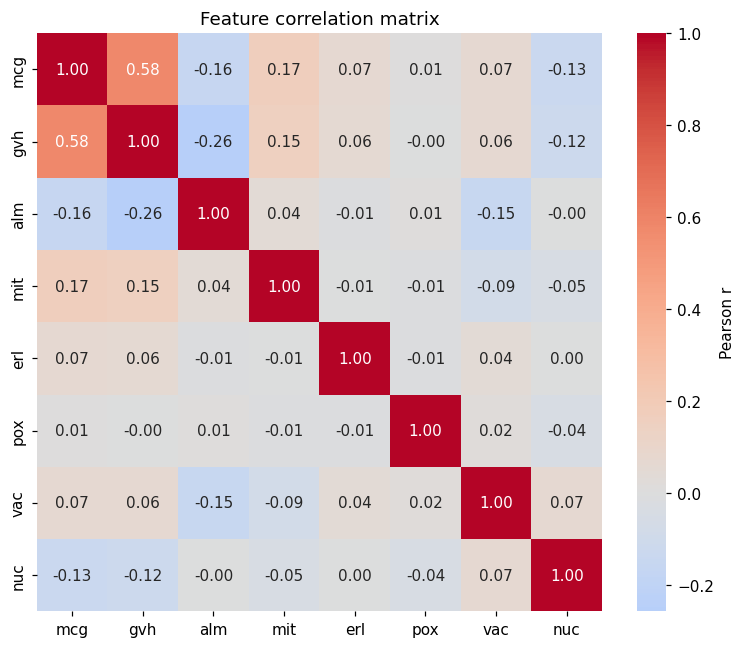

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Feature distribution by class

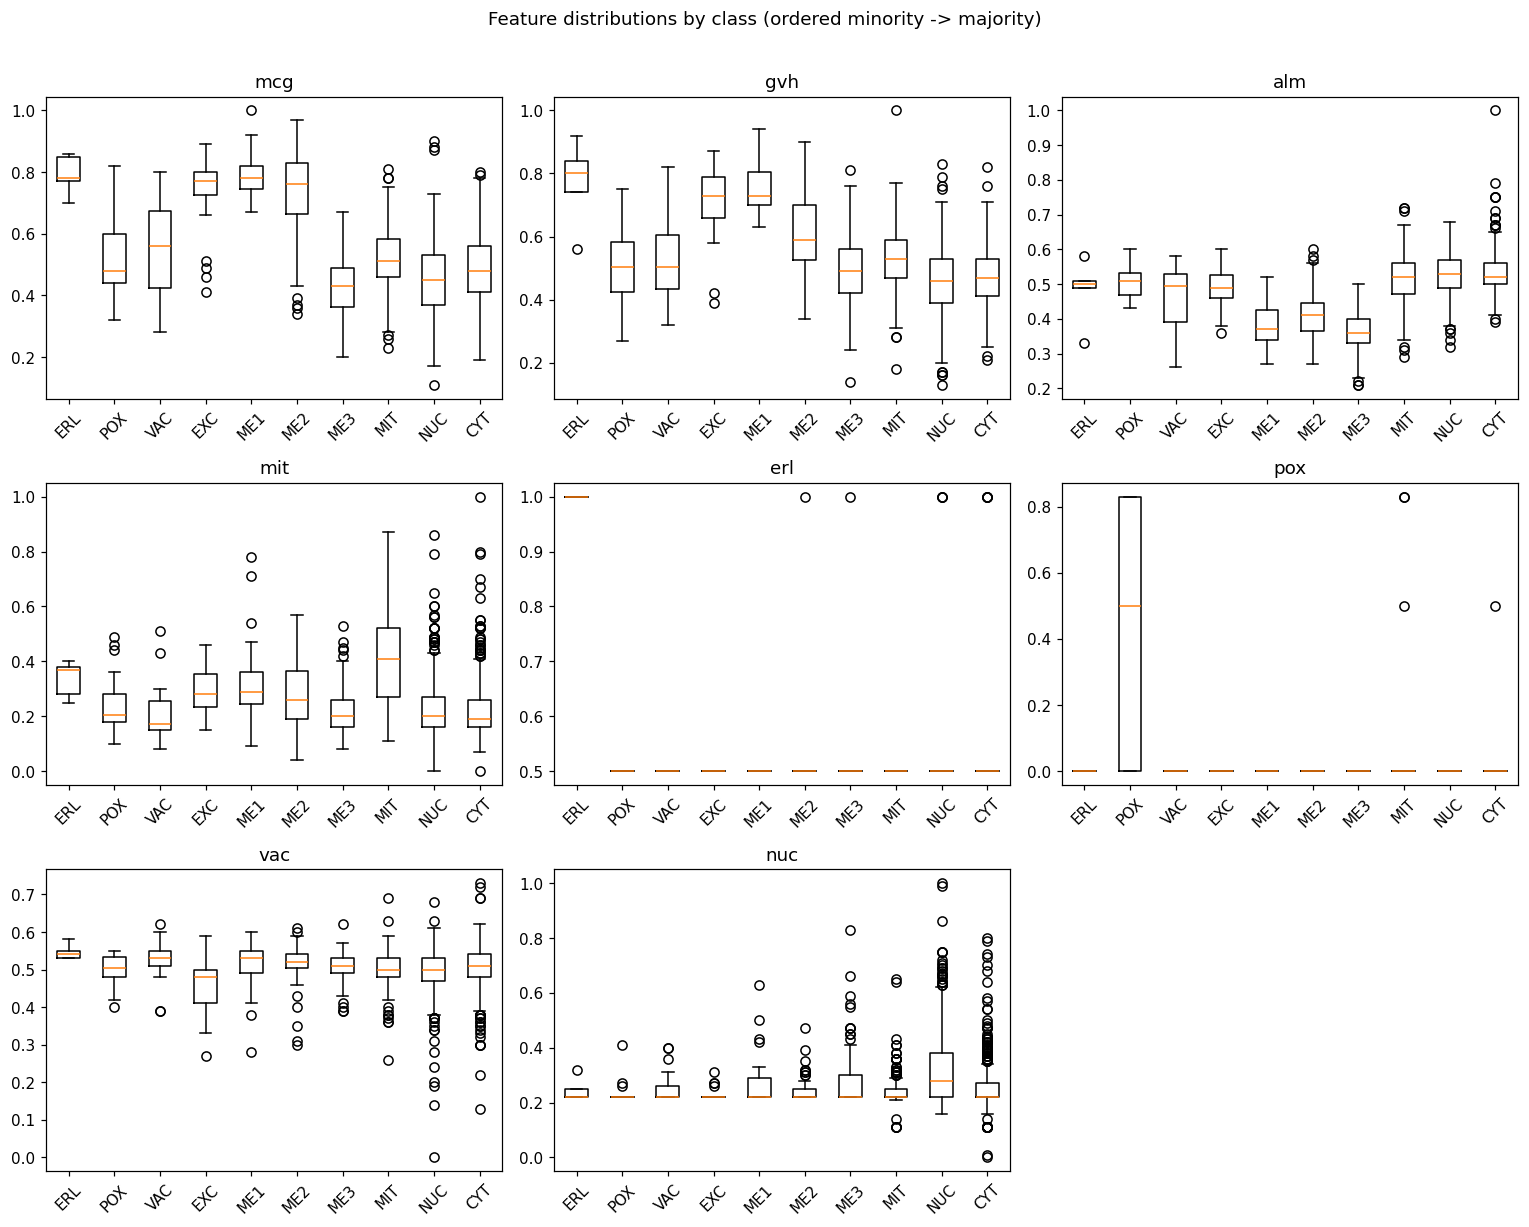

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    data_by_class = [df[df["class"] == c][feat].values for c in minority_to_majority_order]
    axes[i].boxplot(data_by_class, tick_labels=minority_to_majority_order)
    axes[i].set_title(feat)
    axes[i].tick_params(axis="x", rotation=45)
axes[-1].axis("off")  # 8 features in a 3x3 grid leaves one empty panel
plt.suptitle("Feature distributions by class (ordered minority -> majority)", y=1.01)
plt.tight_layout()
plt.show()

mcg and gvh separate ERL, EXC, and ME1 fairly well from the rest (visibly higherboxes), and alm shows a rough increasing trend from ME1 through to CYT. mit and nuc have heavy overlap across almost all classes, so they carry little discriminative power on their own. erl is almost a direct class indicator: it's 1.0 only for ERL and 0.5 everywhere else, which explains why the ERL class is rare rather than hard to detect. pox is similarly close to constant (0 for
almost every class), with only ERL and MIT/CYT showing rare non-zero spikes.

# Saving the data

In [ ]:
df.to_csv(data_dir + "yeast_clean.csv", index=False)
dist_table.to_csv(data_dir + "class_distribution.csv", index=False)
print(f"Saved to {data_dir}")

Saved to /content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Yeast/
